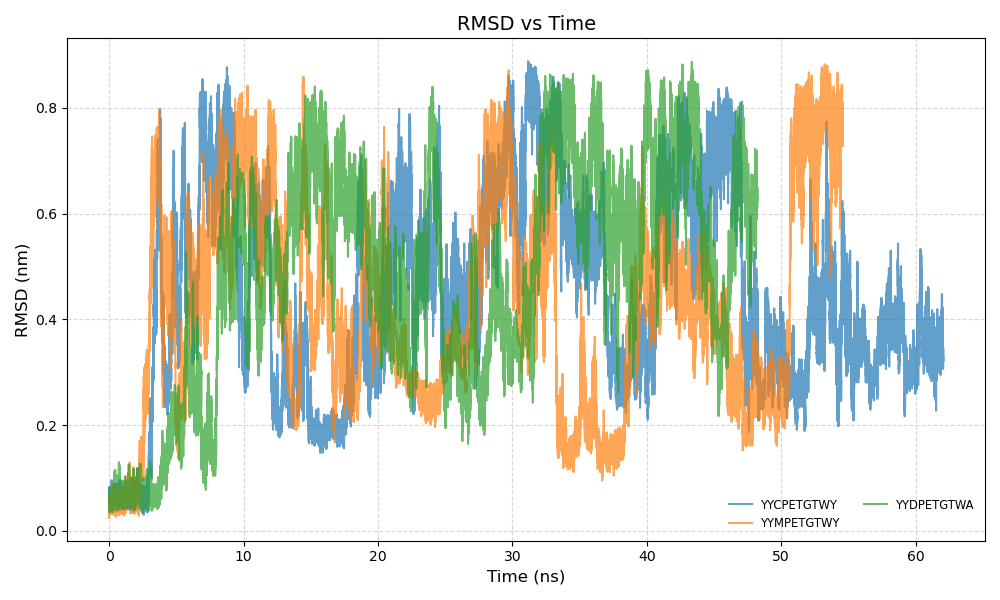

In [19]:
import matplotlib
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_colvar(colvar_file: Path) -> pd.DataFrame:
    # Extract headers from the FIELDS line
    with colvar_file.open() as f:
        headers = None
        for line in f:
            if line.startswith("#! FIELDS"):
                headers = line.replace("#! FIELDS", "").strip().split()
                break
    if headers is None:
        raise ValueError(f"No '#! FIELDS' line found in {colvar_file}")

    # Read the file while skipping all comment lines
    return pd.read_csv(
        colvar_file,
        sep=r"\s+",
        comment="#",
        names=headers,
        engine="python"
    )

proteins = ["YYCPETGTWY", "YYMPETGTWY", "YYDPETGTWA"]

plt.figure(figsize=(10, 6))

for protein_name in proteins:
    base_path = Path(f"../../data/{protein_name}/output")

    all_times = []
    all_rmsd = []

    for i in range(0, 1):  
        run_name = f"run_{i:03d}"
        colvar_file = base_path / run_name / f"COLVAR_{i:03d}"  # <-- COLVAR_000 style

        if not colvar_file.exists():
            print(f"Skipping missing file: {colvar_file}")
            continue

        df = read_colvar(colvar_file)
        all_times.extend(df["time"] * 1e-3)  # convert ps → ns
        all_rmsd.extend(df["rmsd"])

    plt.plot(all_times, all_rmsd, label=protein_name, linewidth=1.5, alpha=0.7)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("RMSD (nm)", fontsize=12)
plt.title("RMSD vs Time", fontsize=14)
plt.legend(fontsize="small", ncol=2, frameon=False)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()


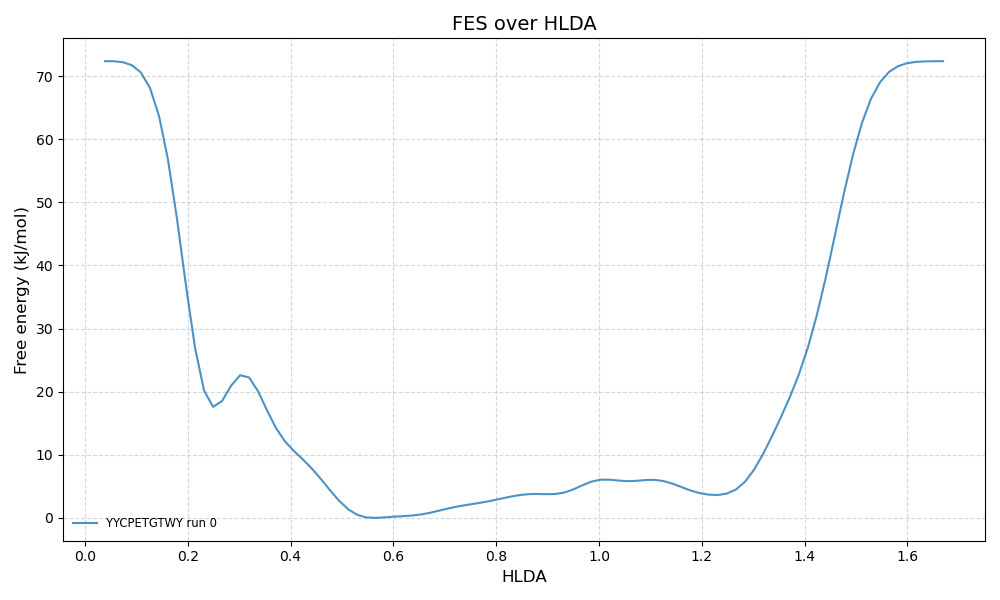

In [17]:
import matplotlib
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

def generate_fes(hills_file: Path, fes_file: Path):
    if not fes_file.exists():
        subprocess.run([
            "plumed", "sum_hills",
            "--hills", str(hills_file),
            "--mintozero",
            "--outfile", str(fes_file)
        ], check=True)

def read_fes(fes_file: Path) -> pd.DataFrame:
    with fes_file.open() as f:
        headers = None
        for line in f:
            if line.startswith("#! FIELDS"):
                headers = line.replace("#! FIELDS", "").strip().split()
                break
    if headers is None:
        raise ValueError(f"No '#! FIELDS' line in {fes_file}")

    return pd.read_csv(
        fes_file,
        sep=r"\s+",
        comment="#",
        names=headers,
        engine="python"
    )

proteins = ["YYCPETGTWY"]

plt.figure(figsize=(10, 6))

for protein_name in proteins:
    base_path = Path(f"../../data/{protein_name}/output")

    for i in range(0, 1):  # adjust range
        run_name = f"run_{i:03d}"
        hills_file = base_path / run_name / f"HILLS{i:03d}"
        fes_file = base_path / run_name / f"FES_{i:03d}.dat"

        if not hills_file.exists():
            print(f"Skipping missing file: {hills_file}")
            continue

        # make FES if missing
        generate_fes(hills_file, fes_file)

        df = read_fes(fes_file)

        if "hlda" not in df.columns:
            print(f"{fes_file} does not contain 'rmsd' column")
            continue

        plt.plot(df["hlda"], df["file.free"],
                 label=f"{protein_name} run {i}", linewidth=1.5, alpha=0.8)

plt.xlabel("HLDA", fontsize=12)
plt.ylabel("Free energy (kJ/mol)", fontsize=12)
plt.title("FES over HLDA", fontsize=14)
plt.legend(fontsize="small", ncol=2, frameon=False)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
